# 01 - SSID Robust Training + Model Comparison

Version orientee SSID uniquement:
- vecteurs RSSI agreges par SSID
- statistiques globales de scan
- comparaison de modeles classiques + petits reseaux de neurones

In [1]:
# Optionnel
# %pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [2]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from robust_localization import (
    build_training_dataset,
    evaluate_models_cv,
    evaluate_models_holdout,
    get_model_zoo,
    train_final_model,
    save_artifacts,
)

In [3]:
RAW_DIR = Path('../data/raw')
ARTIFACT_DIR = Path('./artifacts_robust_ssid')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MAX_SSIDS = 120
MIN_SSID_FREQ = 5
RANDOM_STATE = 42
TEST_SIZE = 0.2
INCLUDE_SLOW_MODEL = False
INCLUDE_NEURAL_MODELS = True

In [4]:
X, y, feature_builder, per_ssid, snapshot = build_training_dataset(
    RAW_DIR,
    max_ssids=MAX_SSIDS,
    min_ssid_frequency=MIN_SSID_FREQ,
)

print('Snapshots:', len(X))
print('Nb features:', X.shape[1])
print('Nb salles:', y.nunique())
print('Nb SSID retenus:', len(feature_builder.selected_ssids))
display(y.value_counts().to_frame('count'))

Snapshots: 1498
Nb features: 74
Nb salles: 24
Nb SSID retenus: 13


,count
room,
S104,97
S101A,86
couloirB(2e),85
P102A,84
PALIER1ER,76
pallierPbas,74
P102B,74
S103B,73
couloirPbasB,69


In [5]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

models = get_model_zoo(
    random_state=RANDOM_STATE,
    include_slow=INCLUDE_SLOW_MODEL,
    include_neural=INCLUDE_NEURAL_MODELS,
)
cv_metrics = evaluate_models_cv(X, y_encoded, models=models, n_splits=3, random_state=RANDOM_STATE)
display(cv_metrics)

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std
0,ExtraTrees,0.977299,0.004739,0.972982,0.005064
1,RandomForest,0.969959,0.002847,0.965893,0.004800
2,LogisticRegression,0.963287,0.002464,0.961393,0.005074
3,MLP_64_32,0.932577,0.009009,0.932597,0.009876
4,MLP_32,0.913212,0.009635,0.910685,0.014617


In [6]:
holdout_metrics, diagnostics = evaluate_models_holdout(
    X, y_encoded, models=models, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
display(holdout_metrics)

best_model_name = diagnostics['best_model_name']
print('Best model:', best_model_name)

,model,test_accuracy,test_f1_macro
0,RandomForest,0.983333,0.982139
1,ExtraTrees,0.983333,0.982139
2,LogisticRegression,0.960000,0.962520
3,MLP_64_32,0.930000,0.932560
4,MLP_32,0.886667,0.889829


Best model: RandomForest


              precision    recall  f1-score   support

       P101A       0.80      1.00      0.89         8
       P101B       1.00      0.82      0.90        11
       P102A       1.00      0.94      0.97        17
       P102B       0.94      1.00      0.97        15
       P103A       1.00      1.00      1.00         6
   PALIER1ER       1.00      1.00      1.00        15
    PALIER2E       1.00      1.00      1.00        14
       S101A       1.00      1.00      1.00        17
       S101B       1.00      1.00      1.00        10
       S102A       1.00      1.00      1.00        12
       S102B       1.00      0.90      0.95        10
       S103B       1.00      1.00      1.00        15
        S104       0.95      1.00      0.98        20
       S202A       0.92      1.00      0.96        11
       S202B       1.00      1.00      1.00        11
       S203A       1.00      1.00      1.00        13
       S203B       1.00      1.00      1.00        12
       S204A       1.00    

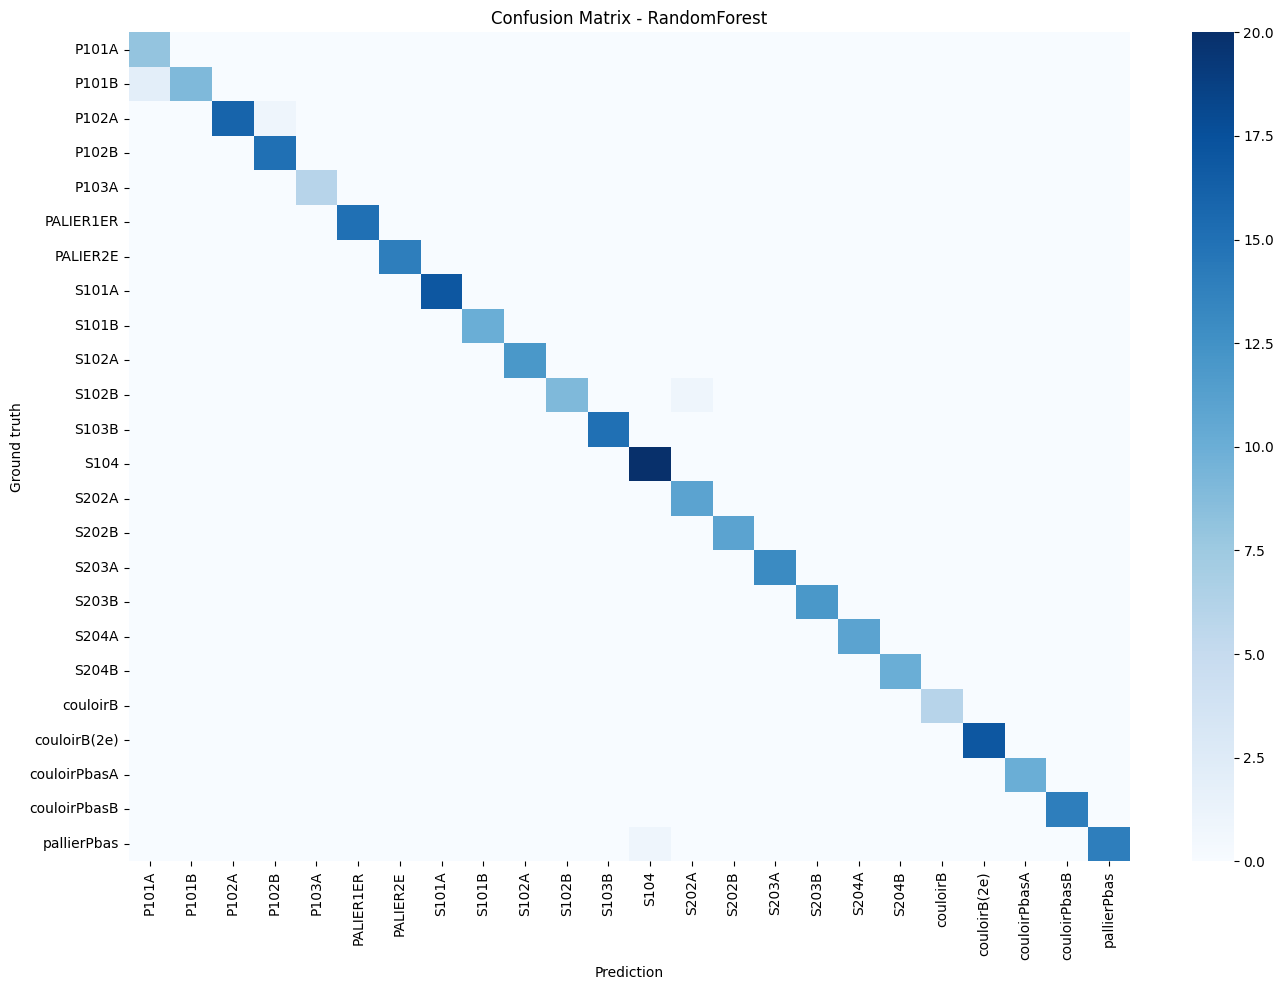

In [7]:
best_holdout_model = diagnostics['best_model_fitted']
X_test = diagnostics['X_test']
y_test = diagnostics['y_test']

y_pred = best_holdout_model.predict(X_test)
target_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Prediction')
plt.ylabel('Ground truth')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'confusion_matrix_robust_ssid.png', dpi=180)
plt.show()

In [8]:
final_model = train_final_model(
    X, y_encoded, model_name=best_model_name, random_state=RANDOM_STATE, include_neural=INCLUDE_NEURAL_MODELS
)

metadata = {
    'feature_scope': 'SSID-only',
    'model_name': best_model_name,
    'n_snapshots': int(len(X)),
    'n_features': int(X.shape[1]),
    'n_rooms': int(y.nunique()),
    'max_ssids': int(MAX_SSIDS),
    'min_ssid_frequency': int(MIN_SSID_FREQ),
    'test_size': float(TEST_SIZE),
    'cv_metrics': cv_metrics.to_dict(orient='records'),
    'holdout_metrics': holdout_metrics.to_dict(orient='records'),
    'label_classes': label_encoder.classes_.tolist(),
}

save_artifacts(ARTIFACT_DIR, final_model, feature_builder, label_encoder, metadata)
with open(ARTIFACT_DIR / 'training_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('Artefacts sauvegardes dans:', ARTIFACT_DIR.resolve())

Artefacts sauvegardes dans: C:\Users\virgi\Documents\UTT_2025\Semestre 4\IF23\IF23_Localisation\project\models\artifacts_robust_ssid
